In [1]:
using LinearAlgebra
using QuantumOptics

"""
Calculates the Quantum Fisher Information and Cramér-Rao Bound 
for a parameter alpha. Automatically handles both pure states (Ket) 
and mixed states (Operator).
"""
function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Ensure they are in dense matrix format so we can access .data
    rho_dense = dense(rho1)
    rho_pert_dense = dense(rho2)

    # 3. Calculate the derivative of the density matrix via finite difference
    drho = (rho_pert_dense - rho_dense) / d_alpha
    
    # 4. Diagonalize the base density matrix
    λ, V = eigen(rho_dense.data)
    
    qfi = 0.0
    n = length(λ)
    
    # 5. Compute the Bures metric sum for Quantum Fisher Information
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # Project drho into the eigenbasis: <i | drho | j>
                drho_ij = dot(V[:, i], drho.data * V[:, j])
                
                # Add to the QFI sum
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    # 6. The Cramér-Rao Bound is the inverse of the QFI
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    
    return qfi, qcrb
end

calculate_qcrb

In [2]:
using IonSim
using QuantumOptics
using PyPlot

In [3]:
# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 1e6 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
# transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)


# Laser 1: Red Sideband (Detuned by -ω_m)
# zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
zeeman_offset =0
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize((im-1) * ion["g"] + ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:25.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0 Hz
Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 2.24458e-10  4.13232e-10  7.45754e-10  …   3.62245e-12  2.44952e-12
 4.13475e-10  7.60242e-10  1.37028e-9       5.35503e-12  3.74836e-12
 7.46636e-10  1.37109e-9   2.46826e-9       7.59774e-12  5.56649e-12
 1.32159e-9   2.42392e-9   4.35835e-9       1.02723e-11  8.0137e-12
 2.29291e-9   4.20038e-9   7.54367e-9       1.3084e-11   1.11749e-11
 3.89912e-9   7.13436e-9   1.27983e-8   …   1.53875e-11  1.50955e-11
 6.49844e-9   1.18768e-8   2.12819e-8       1.60444e-11  1.98002e-11
 1.06144e-8   1.93774e-8   3.46846e-8       1.33384e-11  2.54047e-11
 1.69903e-8   3.09832e-8   5.53999e-8       5.10094e-12  3.24387e-11
 2.66504e-8   4.85474e-8   8.67171e-8      -1.06577e-11  4.25924e-11
 ⋮                                      ⋱                ⋮
 3.52604e-11  3.68084e-11  2.47078e-11      3.31251e-7   1.81582e-7
 2.51615e-11  2.64381e-11  1.76631e-11      2.07264e-7   1.13484e-7
 1.84886e-11  2.03726e-11  1.58327e-11      1.27085e-7   6.95002e-8
 1.37771e-11  1.62479e-11

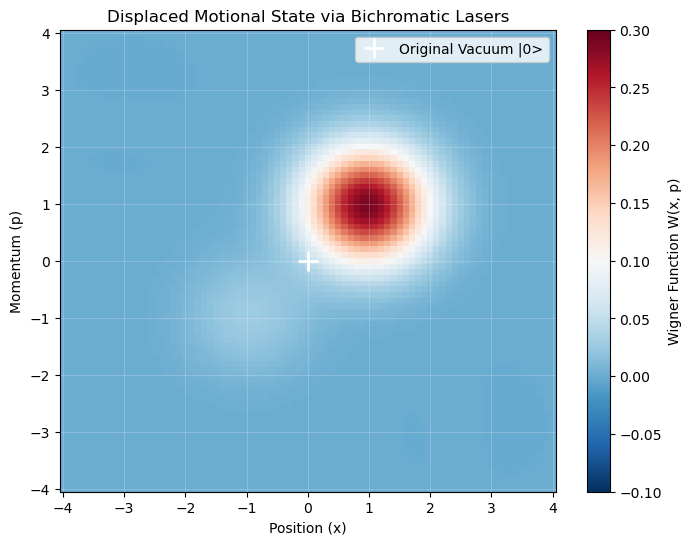

In [4]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [5]:
# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 1e6 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
# transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)


# Laser 1: Red Sideband (Detuned by -ω_m)
# zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
zeeman_offset =0
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
laser_intensity =0
L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize(ion["g"] - ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:50.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0 Hz
Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 4.03113e-15  8.88218e-15  1.91834e-14  …  8.88218e-15  4.03113e-15
 8.88218e-15  1.9571e-14   4.22687e-14     1.9571e-14   8.88218e-15
 1.91834e-14  4.22687e-14  9.12905e-14     4.22687e-14  1.91834e-14
 4.06113e-14  8.94828e-14  1.93262e-13     8.94828e-14  4.06113e-14
 8.42717e-14  1.85684e-13  4.01034e-13     1.85684e-13  8.42717e-14
 1.71408e-13  3.7768e-13   8.157e-13    …  3.7768e-13   1.71408e-13
 3.41739e-13  7.52986e-13  1.62627e-12     7.52986e-13  3.41739e-13
 6.67839e-13  1.47151e-12  3.17812e-12     1.47151e-12  6.67839e-13
 1.27927e-12  2.81874e-12  6.08783e-12     2.81874e-12  1.27927e-12
 2.40197e-12  5.2925e-12   1.14306e-11     5.2925e-12   2.40197e-12
 ⋮                                      ⋱               ⋮
 1.27927e-12  2.81874e-12  6.08783e-12     2.81874e-12  1.27927e-12
 6.67839e-13  1.47151e-12  3.17812e-12     1.47151e-12  6.67839e-13
 3.41739e-13  7.52986e-13  1.62627e-12     7.52986e-13  3.41739e-13
 1.71408e-13  3.7768e-13   8.157e-1

In [6]:
# 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 1 * im + 1

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = I_spin ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * sol[end]

final_state = displaced_final_state

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec) 

81×81 Matrix{Float64}:
 3.36656e-9  5.37582e-9  8.39402e-9  …  1.04082e-8  6.816e-9    4.36238e-9
 5.37582e-9  8.49064e-9  1.31063e-8     1.61194e-8  1.06928e-8  6.92774e-9
 8.39402e-9  1.31063e-8  1.99888e-8     2.43657e-8  1.63835e-8  1.07514e-8
 1.28172e-8  1.97735e-8  2.97776e-8     3.59495e-8  2.45196e-8  1.63076e-8
 1.91403e-8  2.91586e-8  4.33298e-8     5.17781e-8  3.58489e-8  2.41783e-8
 2.79561e-8  4.20297e-8  6.15859e-8  …  7.28192e-8  5.12151e-8  3.50484e-8
 3.99412e-8  5.9221e-8   8.55019e-8     1.00039e-7  7.15217e-8  4.96875e-8
 5.58252e-8  8.15745e-8  1.1595e-7      1.34342e-7  9.76872e-8  6.89207e-8
 7.63411e-8  1.09856e-7  1.53592e-7     1.76532e-7  1.30603e-7  9.35919e-8
 1.02156e-7  1.44651e-7  1.98731e-7     2.27349e-7  1.71119e-7  1.2453e-7
 ⋮                                   ⋱                          ⋮
 8.1667e-8   1.14932e-7  1.56549e-7     3.14128e-5  1.88427e-5  1.10768e-5
 6.1319e-8   8.79195e-8  1.22274e-7     2.08175e-5  1.24399e-5  7.28482e-6
 4.50138e-8 

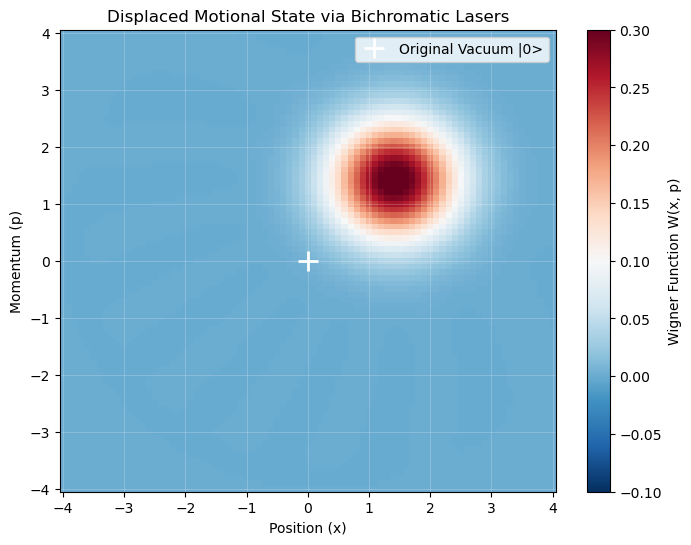

In [7]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


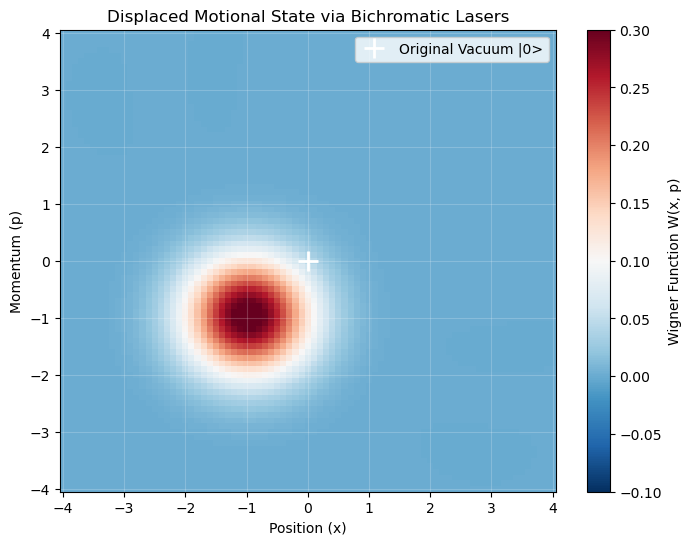

Zeeman Offset: 0 Hz
Simulating bichromatic displacement...


In [8]:

trap_freq = 1e6 # 1 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))
mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10
k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)

zeeman_offset =0
println("Zeeman Offset: ", zeeman_offset, " Hz")

L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
mode = zmodes(trap)[1]
ψ_ion = normalize((1- im) * ion["g"] + ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
tspan = 0:0.5:25.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

final_state = sol[end]

rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


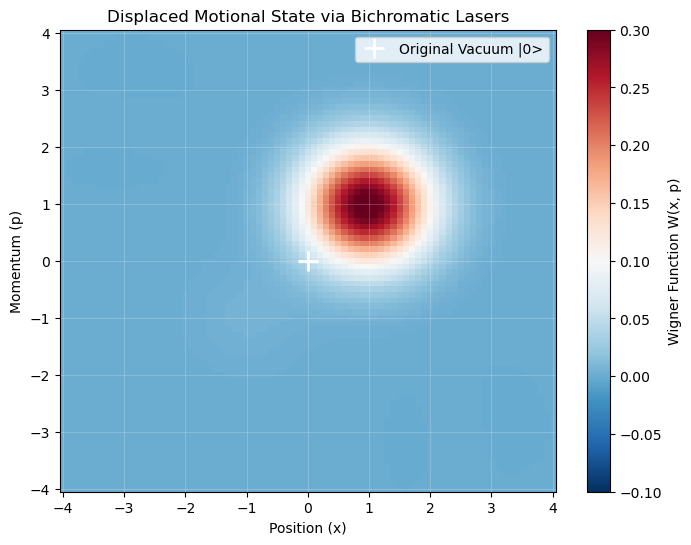

Zeeman Offset: 0 Hz
Simulating bichromatic displacement...


In [9]:

trap_freq = 1e6 # 1 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))
mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10
k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)

zeeman_offset =0
println("Zeeman Offset: ", zeeman_offset, " Hz")

L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
mode = zmodes(trap)[1]
# ψ_ion = normalize(   (1-im)*ion["g"] +ion["e"])
ψ_ion = normalize( exp(im * 3π/4) * ion["g"] + ion["e"] )
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
tspan = 0:0.5:25.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

final_state = sol[end]

rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [10]:
print(D_motion)

Operator(dim=11x11)
  basis: VibrationalMode(ν=1.0e6, axis=ẑ, N=10)
   0.367879+1.0e-17im      -0.367879+0.367879im            0.0-0.52026im       0.300372+0.300372im   -0.300373-0.0im          0.134329-0.134329im          0.0+0.109689im   -0.0414313-0.0414313im   0.0294342+0.0im        -0.00950233+0.00950233im        -0.0-0.00724033im
   0.367879+0.367879im     -0.367879-2.0e-17im     -6.31004e-8+6.31004e-8im        -0.0-0.300372im    0.300375+0.300375im    -0.402972+1.0e-17im      0.219421-0.219421im      4.0e-17+0.206957im   -0.0886785-0.0886785im    0.0654066+0.0im          -0.030049+0.030049im
    1.0e-17+0.52026im     6.31004e-8+6.31004e-8im    -0.367879-1.0e-17im       0.212399-0.212399im     1.0e-17-3.0531e-5im    0.189871+0.189871im    -0.388349+1.0e-17im      0.262439-0.262439im     -1.0e-17+0.295979im     -0.127643-0.127643im      0.151373-1.0e-17im
  -0.300372+0.300372im      -2.0e-17+0.300372im      -0.212399-0.212399im     -0.122661-0.0im         0.245125-0.245125im     

In [11]:
print(rho_motional)

Operator(dim=11x11)
  basis: VibrationalMode(ν=1.0e6, axis=ẑ, N=10)
    0.390788+0.0im             0.259089-0.259225im      6.38942e-6-0.2596im         -0.0990153-0.0989701im      -0.0697872-3.61327e-6im    -0.0205289+0.0205367im    -9.59157e-7+0.0117627im     0.00291422+0.00291337im     0.00143939+1.92984e-7im   0.000310914-0.000311166im   4.49569e-7-0.000149164im
    0.259089+0.259225im        0.367942+0.0im             0.172353-0.172053im       4.30893e-6-0.140497im       -0.0462361-0.0463729im     -0.0291284-2.0025e-6im    -0.00782284+0.00779042im   -4.65178e-7+0.00413135im    0.000952961+0.000958095im  0.000440732-5.03998e-8im    9.97228e-5-9.85517e-5im
  6.38942e-6+0.2596im          0.172353+0.172053im        0.172453+0.0im              0.065723-0.0658328im      1.25969e-6-0.0463601im     -0.0136543-0.0136327im    -0.00781407-4.4504e-7im    -0.00193469+0.00193757im    -1.04697e-7+0.000956207im  0.000206882+0.00020647im    9.90925e-5+2.95377e-7im
  -0.0990153+0.0989701im     4.30

Zeeman Offset: 0 Hz
Simulating bichromatic displacement...


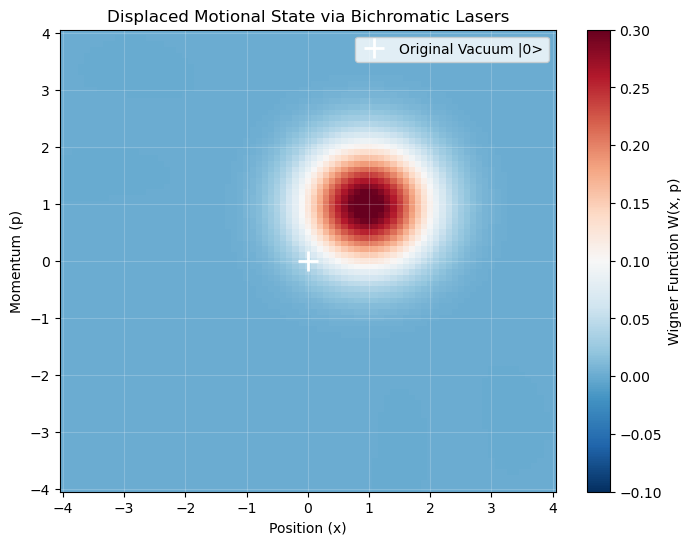

In [12]:

trap_freq = 1e6 # 1 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))
mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10
k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)

zeeman_offset =0
println("Zeeman Offset: ", zeeman_offset, " Hz")

L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
mode = zmodes(trap)[1]
# ψ_ion = normalize(   (1-im)*ion["g"] +ion["e"])
ψ_ion = normalize( (-1+im) * ion["g"] + 2*ion["e"] )
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
tspan = 0:0.5:25.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

final_state = sol[end]

rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


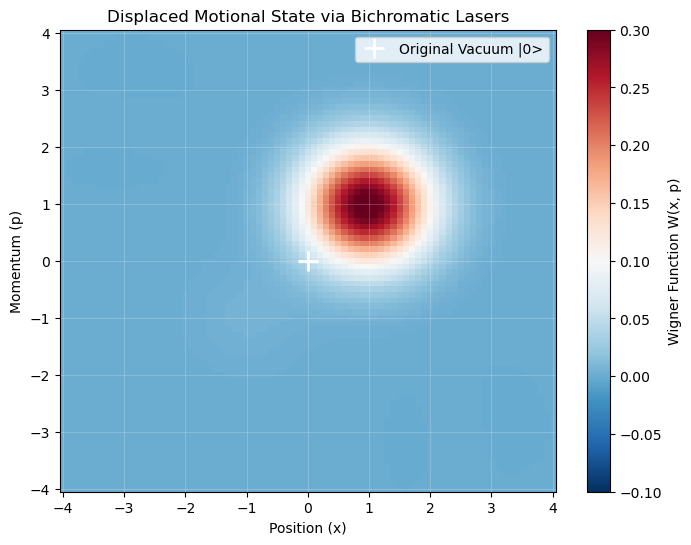

Zeeman Offset: 0 Hz
Simulating bichromatic displacement...


In [13]:

trap_freq = 1e6 # 1 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))
mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10
k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)

zeeman_offset =0
println("Zeeman Offset: ", zeeman_offset, " Hz")

L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
mode = zmodes(trap)[1]
# ψ_ion = normalize(   (1-im)*ion["g"] +ion["e"])
ψ_ion = normalize( exp(im * -5π/4) * ion["g"] + ion["e"] )
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
tspan = 0:0.5:25.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

final_state = sol[end]

rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


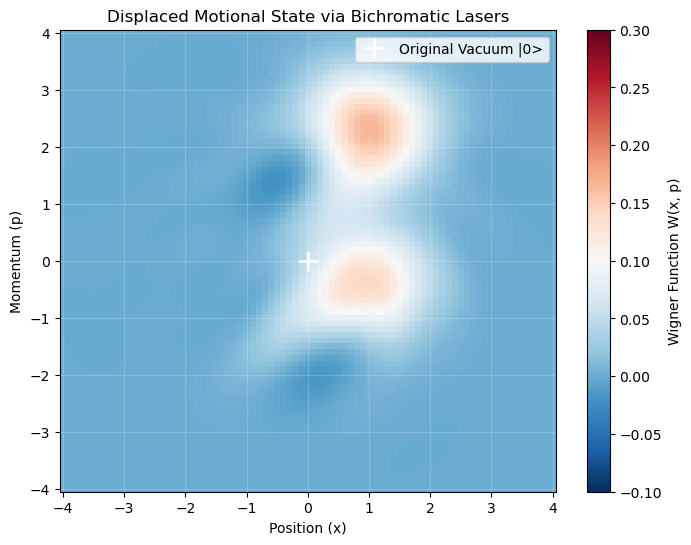

Zeeman Offset: 0 Hz
Simulating bichromatic displacement...


In [14]:

trap_freq = 1e6 # 1 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))
mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10
k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)

zeeman_offset =0
println("Zeeman Offset: ", zeeman_offset, " Hz")

L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=π/4,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=5π/4,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
mode = zmodes(trap)[1]
# ψ_ion = normalize(   (1-im)*ion["g"] +ion["e"])
ψ_ion = normalize( exp(im * -5π/4) * ion["g"] + ion["e"] )
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
tspan = 0:0.5:25.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, final_state, h)

final_state = sol[end]

rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
